# Tree Reconstruction


## 1. Import Libraries and Load Data

In [38]:
# Import libraries
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add the main project folder to Python's search path
project_dir = Path("..").resolve()

if str(project_dir) not in sys.path:
    sys.path.append(str(project_dir))

# Import dataset class
from src.dataset import TreeDataset

In [39]:
# Dataset location
data_dir = project_dir / "data/raw/Dataset (With Summer GT)"

# Create dataset
dataset = TreeDataset(data_dir)

# Select one tree for initial reconstruction
tree = dataset.get_tree("R01N03")

print("Tree:", tree.tree_id)
print("Summer RGB:", tree.summer_rgb.shape)
print("Summer Depth:", tree.summer_depth.shape)
print("Summer GT:", tree.summer_gt.shape)
print("Winter RGB:", tree.winter_rgb.shape)
print("Winter Depth:", tree.winter_depth.shape)

Tree: R01N03
Summer RGB: (480, 640, 3)
Summer Depth: (480, 640, 3)
Summer GT: (256, 256)
Winter RGB: (480, 640, 3)
Winter Depth: (480, 640, 3)


## 2. Preprocess Input Data

### 2.1 Check the depth channels

In [40]:
# Check whether the three depth channels contain identical values

summer_channels_equal = (
    np.array_equal(tree.summer_depth[:, :, 0], tree.summer_depth[:, :, 1])
    and
    np.array_equal(tree.summer_depth[:, :, 1], tree.summer_depth[:, :, 2])
)

winter_channels_equal = (
    np.array_equal(tree.winter_depth[:, :, 0], tree.winter_depth[:, :, 1])
    and
    np.array_equal(tree.winter_depth[:, :, 1], tree.winter_depth[:, :, 2])
)

print("Summer depth channels identical:", summer_channels_equal)
print("Winter depth channels identical:", winter_channels_equal)

Summer depth channels identical: True
Winter depth channels identical: True


In [41]:
# The depth PNG stores identical information in all three channels,
# so only one channel is required.

summer_depth = tree.summer_depth[:, :, 0]
winter_depth = tree.winter_depth[:, :, 0]

print("Summer depth shape:", summer_depth.shape)
print("Winter depth shape:", winter_depth.shape)

Summer depth shape: (480, 640)
Winter depth shape: (480, 640)


### 2.2 Identify valid depth pixels

In [42]:
print("Summer depth range:", summer_depth.min(), "-", summer_depth.max())
print("Winter depth range:", winter_depth.min(), "-", winter_depth.max())

print("Summer zero pixels:", np.sum(summer_depth == 0))
print("Winter zero pixels:", np.sum(winter_depth == 0))

print(
    "Summer zero percentage:",
    round(100 * np.mean(summer_depth == 0), 2),
    "%"
)

print(
    "Winter zero percentage:",
    round(100 * np.mean(winter_depth == 0), 2),
    "%"
)

Summer depth range: 0 - 161
Winter depth range: 0 - 151
Summer zero pixels: 18648
Winter zero pixels: 131022
Summer zero percentage: 6.07 %
Winter zero percentage: 42.65 %


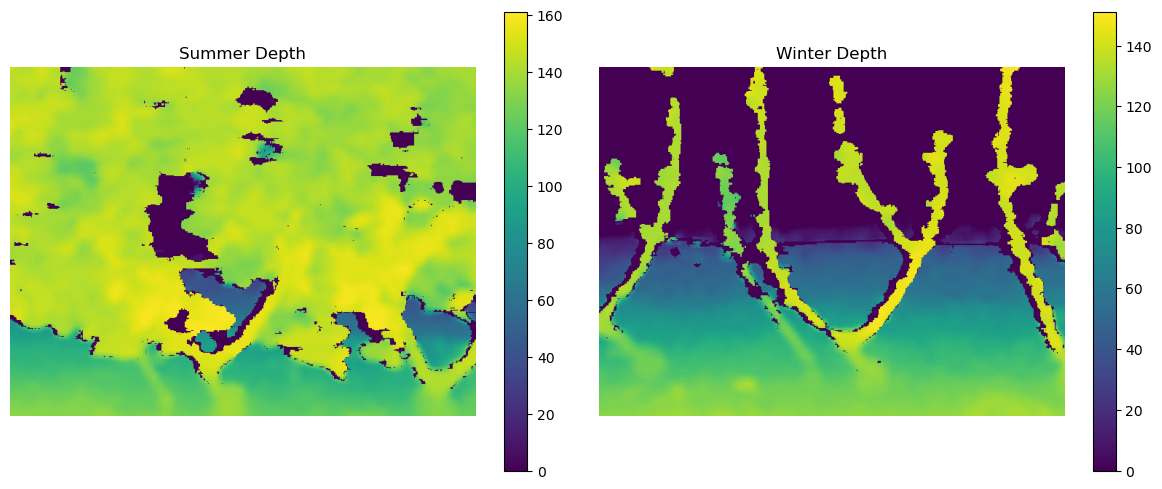

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(summer_depth, cmap="viridis")
axes[0].set_title("Summer Depth")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(winter_depth, cmap="viridis")
axes[1].set_title("Winter Depth")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## 3. Compare RGB and Depth Observations



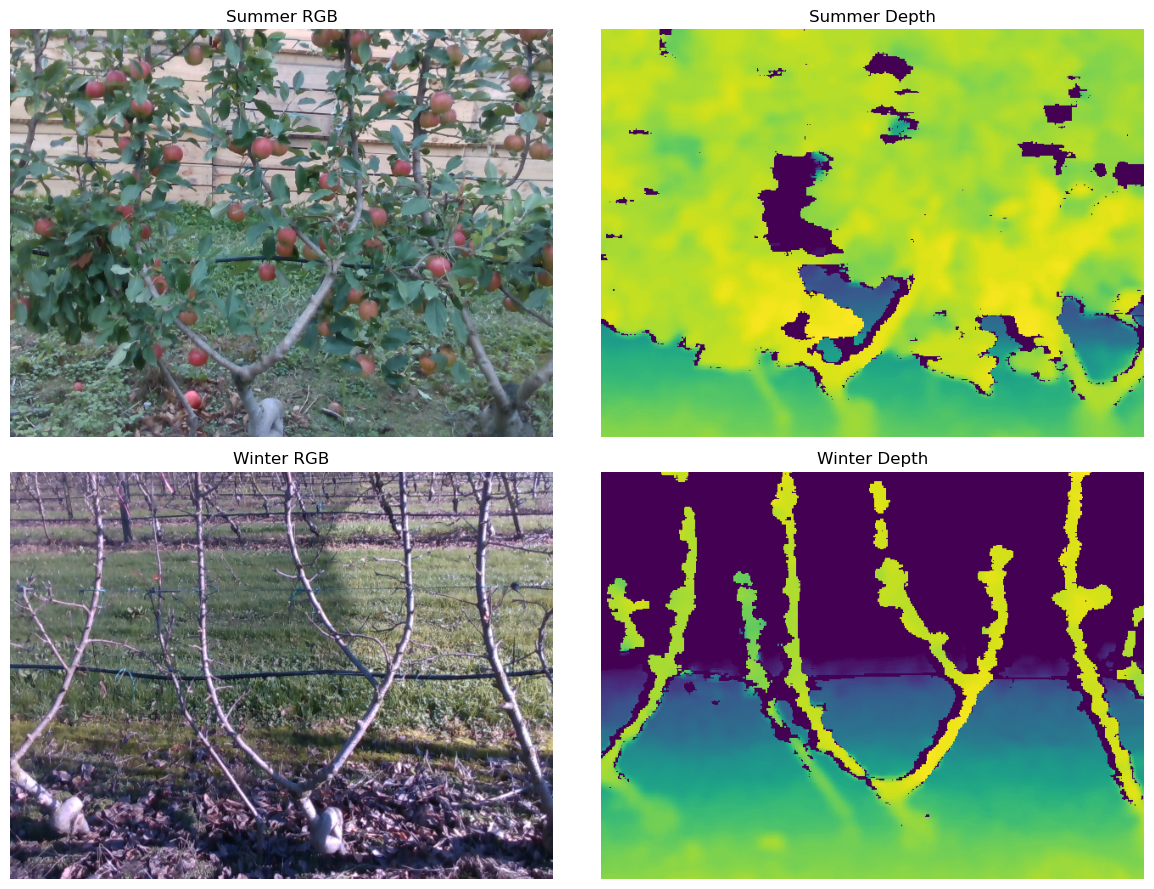

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].imshow(tree.summer_rgb)
axes[0, 0].set_title("Summer RGB")

axes[0, 1].imshow(summer_depth, cmap="viridis")
axes[0, 1].set_title("Summer Depth")

axes[1, 0].imshow(tree.winter_rgb)
axes[1, 0].set_title("Winter RGB")

axes[1, 1].imshow(winter_depth, cmap="viridis")
axes[1, 1].set_title("Winter Depth")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

### RGB-D Observations

The RGB and depth observations have the same image dimensions of 640 × 480 pixels. Visual comparison suggests that for the winter tree the depth is accurate at matching the branch however for the summer the depth just picks up the leaves.

The winter observation provides greater visibility of the tree's branch structure because there is less in the way of the camera to the branches.

## 4. Select Reconstruction Input  

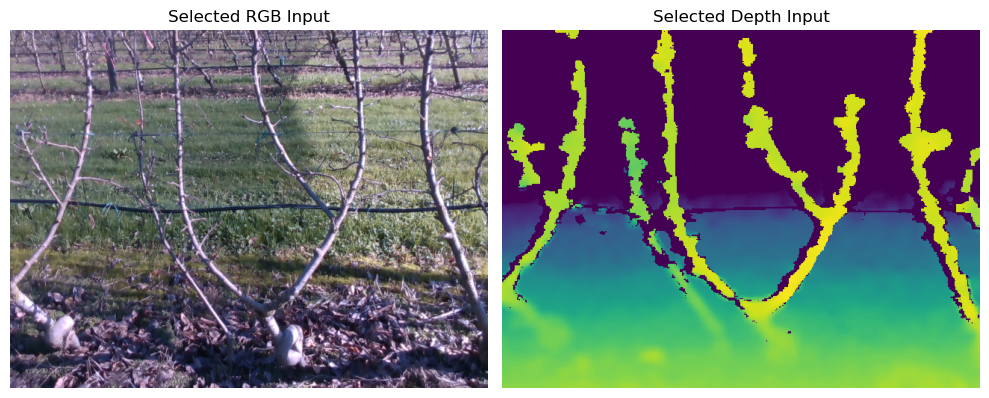

In [45]:
# Use winter observation for initial reconstruction
rgb = tree.winter_rgb
depth = winter_depth

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(rgb)
axes[0].set_title("Selected RGB Input")

axes[1].imshow(depth, cmap="viridis")
axes[1].set_title("Selected Depth Input")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Selected Input

The winter observation was selected for the initial reconstruction because the reduced foliage provides greater visibility of the tree's branch structure.

A reconstruction method will first be developed using a single tree before being applied to additional trees.

## 5. Isolate the Tree


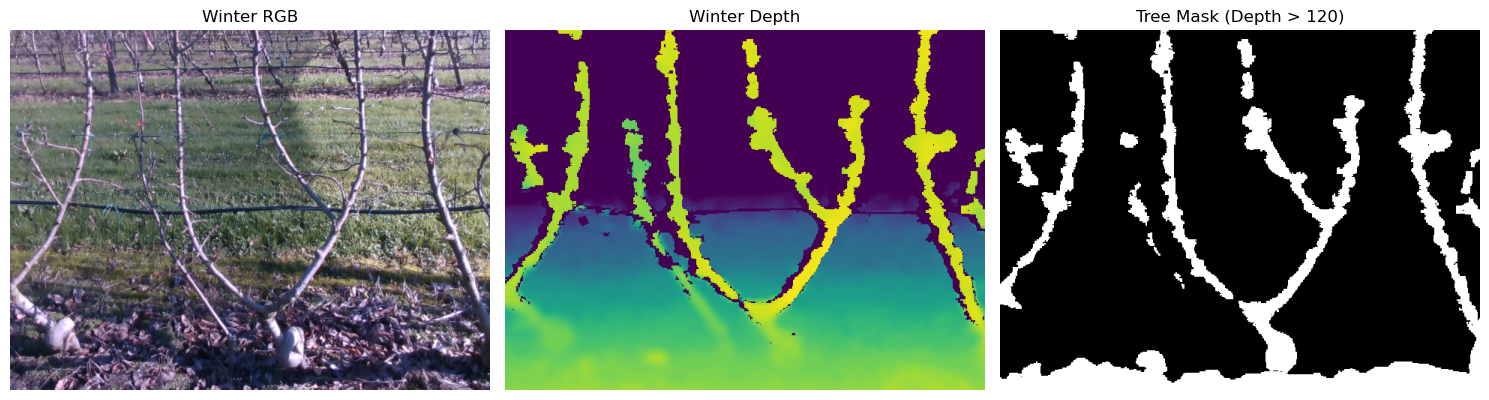

In [53]:
# Segment the tree using a depth threshold
depth_threshold = 120
tree_mask = depth > depth_threshold

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb)
axes[0].set_title("Winter RGB")

axes[1].imshow(depth, cmap="viridis")
axes[1].set_title("Winter Depth")

axes[2].imshow(tree_mask, cmap="gray")
axes[2].set_title(f"Tree Mask (Depth > {depth_threshold})")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Depth-Based Tree Segmentation

The winter depth image showed that the tree could be approximately isolated using a depth threshold. Pixels with depth values greater than 120 were classified as belonging to the tree.

A threshold of 120 was initially selected through visual inspection of the resulting mask. The sensitivity of the reconstruction to this threshold will be investigated later to determine whether this value provides a suitable segmentation.

Number of tree pixels: 54640
Minimum tree depth: 121
Maximum tree depth: 151
Mean tree depth: 132.34668740849196
Median tree depth: 132.0


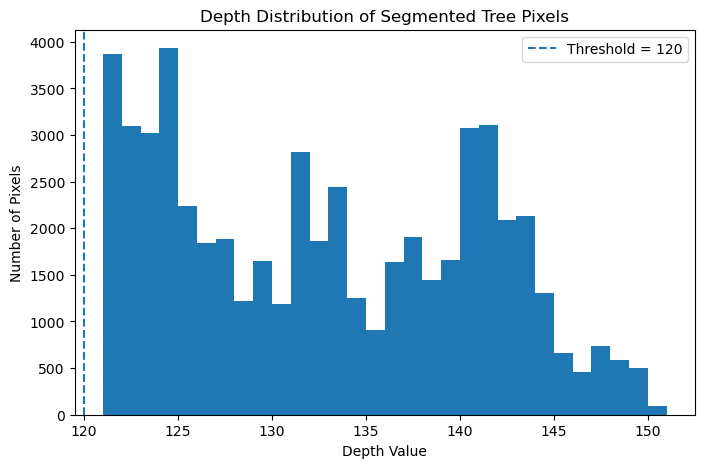

In [47]:
# Analyse depth values classified as part of the tree

tree_depth_values = depth[tree_mask]

print("Number of tree pixels:", len(tree_depth_values))
print("Minimum tree depth:", tree_depth_values.min())
print("Maximum tree depth:", tree_depth_values.max())
print("Mean tree depth:", tree_depth_values.mean())
print("Median tree depth:", np.median(tree_depth_values))

# Plot distribution of tree depth values
plt.figure(figsize=(8, 5))

plt.hist(tree_depth_values, bins=30)

plt.axvline(
    depth_threshold,
    linestyle="--",
    label=f"Threshold = {depth_threshold}"
)

plt.xlabel("Depth Value")
plt.ylabel("Number of Pixels")
plt.title("Depth Distribution of Segmented Tree Pixels")
plt.legend()

plt.show()

### Segmentation Analysis

The depth threshold of 120 separates the higher depth values associated with the tree from much of the surrounding scene. The distribution above shows the range of depth values retained by the segmentation.

The threshold was initially selected through visual inspection. Its effect on the reconstruction will be investigated later by varying the threshold and comparing the resulting tree skeletons.

## Smoothening data

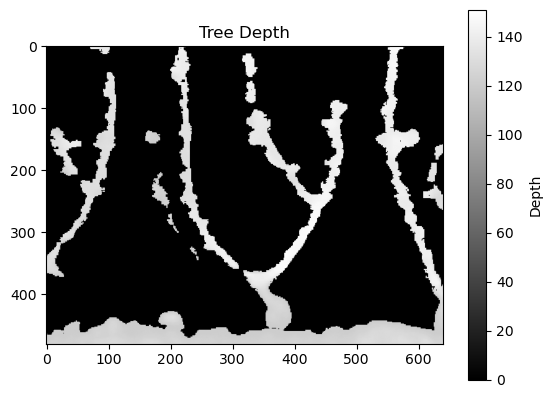

[140 140 141 ... 127 127 127]


In [48]:
tree_depth = np.zeros_like(depth)
tree_depth[tree_mask] = depth[tree_mask]

plt.imshow(tree_depth, cmap="gray")
plt.colorbar(label="Depth")
plt.title("Tree Depth")
plt.show()
print(tree_depth[tree_mask])

### Isolating the Main Tree

The depth threshold also detects some objects that are not part of the tree.
To remove these, the non-zero pixels are separated into connected groups.

Pixels are considered part of the same group if they are touching. The number
of pixels in each connected group is then counted. The largest connected group
is assumed to represent the main tree, while the smaller disconnected groups
are treated as noise and removed.

Number of groups: 17
Size of largest group: 38236


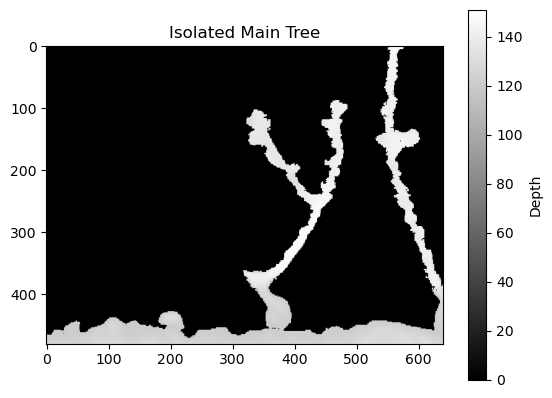

In [49]:
# Find all non-zero pixels
binary_tree = tree_depth > 0

# Keep track of pixels already checked
visited = np.zeros(binary_tree.shape, dtype=bool)

groups = []

rows, cols = binary_tree.shape

# Check every pixel
for row in range(rows):
    for col in range(cols):

        # Start a new group if this pixel is non-zero and hasn't been checked
        if binary_tree[row, col] and not visited[row, col]:

            group = []
            stack = [(row, col)]

            while stack:
                r, c = stack.pop()

                if visited[r, c]:
                    continue

                visited[r, c] = True

                if not binary_tree[r, c]:
                    continue

                group.append((r, c))

                # Check all 8 neighbouring pixels
                for dr in [-1, 0, 1]:
                    for dc in [-1, 0, 1]:

                        nr = r + dr
                        nc = c + dc

                        if (0 <= nr < rows and
                            0 <= nc < cols and
                            not visited[nr, nc]):

                            stack.append((nr, nc))

            groups.append(group)

# Find largest connected group
largest_group = max(groups, key=len)

print("Number of groups:", len(groups))
print("Size of largest group:", len(largest_group))

# Create mask for largest group
main_tree_mask = np.zeros(binary_tree.shape, dtype=bool)

for row, col in largest_group:
    main_tree_mask[row, col] = True

# Keep depth values only for main tree
main_tree_depth = np.where(main_tree_mask, depth, 0)

# Display
plt.imshow(main_tree_depth, cmap="gray")
plt.colorbar(label="Depth")
plt.title("Isolated Main Tree")
plt.show()

I could have used imports to do this however i chose to use a more analog approach as to give more freedom with the selection of what counts so that i could adapt it to see what would work best. 
I had tried with with another tree and it worked however when i changed it to this one it included the ground it in which causes an issue. 

From here i decided to include another input of the colour to validate the isolation of the tree
My next section will be isolating the tree using colour. 

## RGB colour isolation

Find range of image colours

In [77]:
import plotly.express as px

fig = px.imshow(rgb)
fig.show()

Collecting sample data from the tree gives these colours:
    [117,121,164],
    [57,65,103],
    [46,49,70],
    [131,116,136],
    [227,214,245],
    [55,53,83],
    [59,48,81],
    [157,142,183],
    [186,165,205]


Collecting sample data from the grass gives these colours:
    [93, 108, 92],
    [78, 96, 90],
    [145, 149, 176],
    [137, 142, 147],
    [109, 122, 107],
    [71, 86, 70],
    [101, 108, 86],
    [150, 150, 119],
    [162, 165, 113]

In [78]:
tree_colours = np.array([
    [117,121,164],
    [57,65,103],
    [46,49,70],
    [131,116,136],
    [227,214,245],
    [55,53,83],
    [59,48,81],
    [157,142,183],
    [186,165,205]
])
tree_colours.min(axis=0)
tree_colours.max(axis=0)
R = tree_colours[:, 0]
G = tree_colours[:, 1]
B = tree_colours[:, 2]

print("G - R:", G - R)
print("B - R:", B - R)
print("B - G:", B - G)

G - R: [  4   8   3 -15 -13  -2 -11 -15 -21]
B - R: [47 46 24  5 18 28 22 26 19]
B - G: [43 38 21 20 31 30 33 41 40]


In [79]:
grass_colours = np.array([
    [93, 108, 92],
    [78, 96, 90],
    [145, 149, 176],
    [137, 142, 147],
    [109, 122, 107],
    [71, 86, 70],
    [101, 108, 86],
    [150, 150, 119],
    [162, 165, 113]
])
tree_BG = tree_colours[:, 2] - tree_colours[:, 1]
print(tree_BG)
grass_BG = grass_colours[:, 2] - grass_colours[:, 1]
print(grass_BG)

[43 38 21 20 31 30 33 41 40]
[-16  -6  27   5 -15 -16 -22 -31 -52]


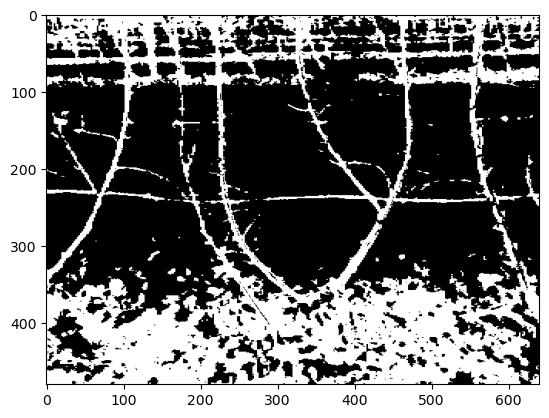

In [82]:
R = rgb[:, :, 0]
G = rgb[:, :, 1]
B = rgb[:, :, 2]
colour_mask = (B.astype(int) - G.astype(int)) > 18
plt.imshow(colour_mask, cmap="gray")
plt.show()

The colour isolation did not do what was intended as the bark on the ground and the tree were too close together ont he colour spectrum to isolate. However what it does do is it is better at capturing the small branches then the depth was, so i am going to use this in conjunction with the depth isolation to get a better image of the tree. 

### using colour with depth to isolate tree

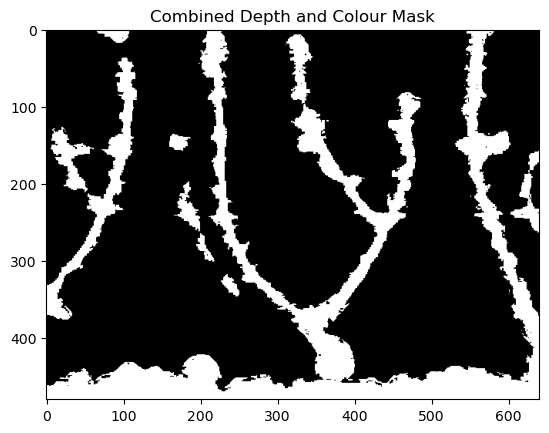

In [96]:
from scipy.ndimage import binary_dilation
expanded_depth = binary_dilation(tree_mask, iterations=5)
connected_colour = colour_mask & expanded_depth
combined_mask = tree_mask | connected_colour
plt.imshow(combined_mask, cmap="gray")
plt.title("Combined Depth and Colour Mask")
plt.show()

As the ground is still causing an issue i am going to remove any line that is all while across it

Number of groups: 38
Size of largest group: 19998


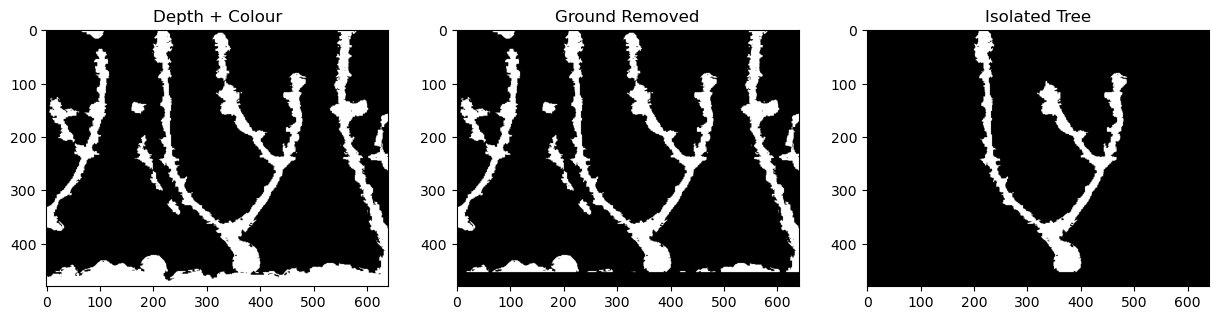

In [105]:
# --------------------------------------------------
# REMOVE GROUND
# --------------------------------------------------

# Count how many detected pixels are in each row
row_counts = np.sum(combined_mask, axis=1)

# Find the fraction of each row that is detected
row_fraction = row_counts / combined_mask.shape[1]

# Rows where more than 70% of pixels are detected are assumed to be ground
ground_rows = row_fraction > 0.70

# Copy the combined mask and remove the ground rows
ground_removed = combined_mask.copy()
ground_removed[ground_rows, :] = False


# --------------------------------------------------
# FIND CONNECTED GROUPS
# --------------------------------------------------

binary_tree = ground_removed

# Keep track of pixels already checked
visited = np.zeros(binary_tree.shape, dtype=bool)

groups = []

rows, cols = binary_tree.shape

# Check every pixel
for row in range(rows):
    for col in range(cols):

        # Start a new group if this pixel is white and hasn't been checked
        if binary_tree[row, col] and not visited[row, col]:

            group = []
            stack = [(row, col)]

            while stack:
                r, c = stack.pop()

                if visited[r, c]:
                    continue

                visited[r, c] = True

                if not binary_tree[r, c]:
                    continue

                group.append((r, c))

                # Check all 8 neighbouring pixels
                for dr in [-1, 0, 1]:
                    for dc in [-1, 0, 1]:

                        nr = r + dr
                        nc = c + dc

                        if (0 <= nr < rows and
                            0 <= nc < cols and
                            not visited[nr, nc]):

                            stack.append((nr, nc))

            groups.append(group)


# --------------------------------------------------
# KEEP LARGEST CONNECTED GROUP
# --------------------------------------------------

largest_group = max(groups, key=len)

print("Number of groups:", len(groups))
print("Size of largest group:", len(largest_group))

# Create an empty mask
main_tree_mask = np.zeros(binary_tree.shape, dtype=bool)

# Add the largest group to the mask
for row, col in largest_group:
    main_tree_mask[row, col] = True


# --------------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(combined_mask, cmap="gray")
axes[0].set_title("Depth + Colour")

axes[1].imshow(ground_removed, cmap="gray")
axes[1].set_title("Ground Removed")

axes[2].imshow(main_tree_mask, cmap="gray")
axes[2].set_title("Isolated Tree")

plt.show()

## compare results

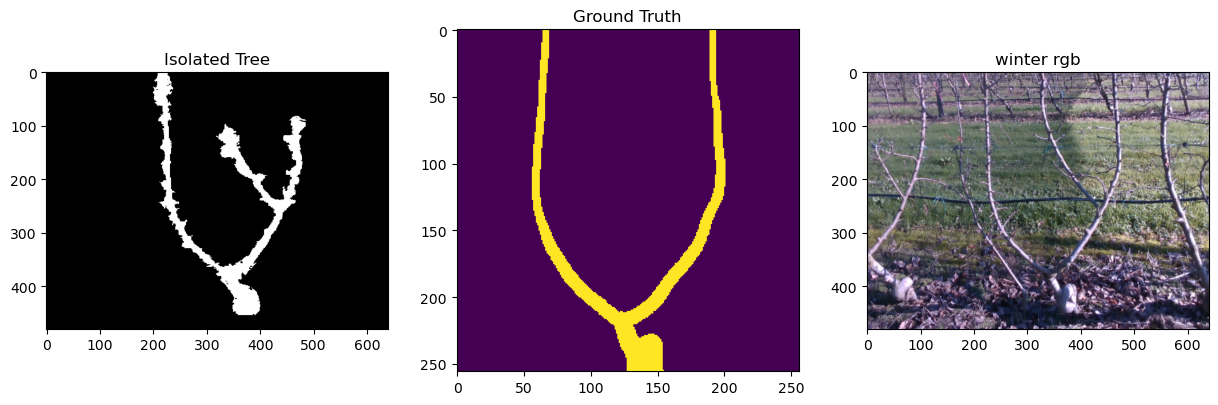

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(main_tree_mask, cmap="gray")
axes[0].set_title("Isolated Tree")

axes[1].imshow(tree.summer_gt, cmap="viridis")
axes[1].set_title("Ground Truth")

axes[2].imshow(tree.winter_rgb, cmap="viridis")
axes[2].set_title("winter rgb")
plt.show()


## 3D Tree Reconstruction

In [110]:
# Find the pixel locations belonging to the isolated tree
y, x = np.where(main_tree_mask)

# Get the depth at those pixel locations
z = depth[y, x]

# Remove pixels with no valid depth
valid = z > 0

x = x[valid]
y = y[valid]
z = z[valid]

# Combine x, y and depth into 3D points
points_3d = np.column_stack((x, y, z))
print(points_3d.shape)
print(points_3d[:10])

(18644, 3)
[[214   0 143]
 [215   0 143]
 [216   0 143]
 [217   0 143]
 [218   0 143]
 [219   0 143]
 [220   0 143]
 [221   0 143]
 [222   0 143]
 [223   0 143]]


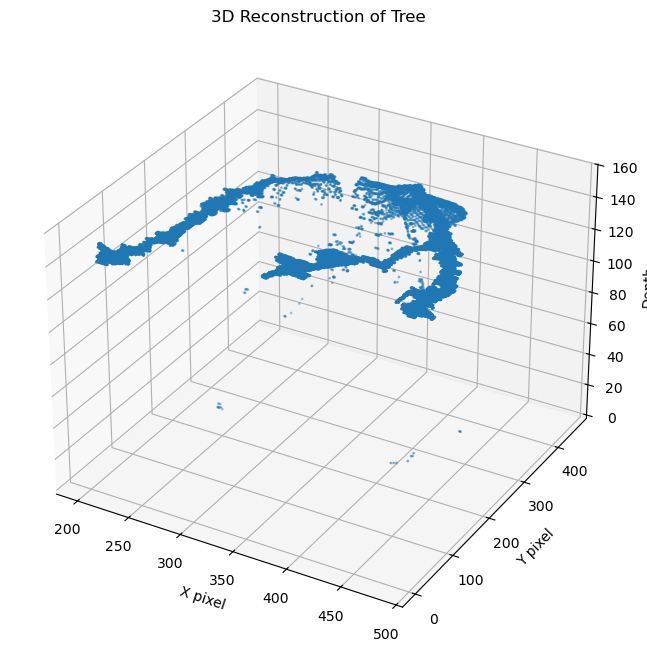

In [111]:
# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot tree pixels
ax.scatter(x, y, z, s=1)

# Labels
ax.set_xlabel("X pixel")
ax.set_ylabel("Y pixel")
ax.set_zlabel("Depth")

ax.set_title("3D Reconstruction of Tree")

plt.show()

In [114]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x,
            y=y,
            z=z,
            mode="markers",
            marker=dict(size=2)
        )
    ]
)

fig.update_layout(
    title="3D Reconstruction of Tree",
    scene=dict(
        xaxis_title="X pixel",
        yaxis_title="Y pixel",
        zaxis_title="Depth"
    )
)

fig.show()